In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Find project root by looking for requirements.txt (works regardless of cwd)
def find_project_root(marker="requirements.txt"):
    current = Path.cwd().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker} in any parent directory")

PROJECT_ROOT = find_project_root()
DATA_RAW = PROJECT_ROOT / "data" / "raw"

# Plot styling — consistent with the Day 1 notebook
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 100

# Team colours — keyed by name so they stay consistent across charts
TEAM_COLORS = {
    "Red Bull": "#3671C6",
    "Red Bull Racing": "#3671C6",
    "Ferrari": "#E10600",
    "McLaren": "#FF8000",
    "Mercedes": "#00D2BE",
    "Aston Martin": "#229971",
    "Alpine F1 Team": "#0093CC",
    "Alpine": "#0093CC",
    "Williams": "#64C4FF",
    "RB F1 Team": "#6692FF",
    "RB": "#6692FF",
    "AlphaTauri": "#2B4562",
    "Kick Sauber": "#52E252",
    "Alfa Romeo": "#900000",
    "Haas F1 Team": "#B6BABD",
}

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/ompatil9819gmail.com/F1-Race-Predictor


In [2]:
seasons = []
for year in [2022, 2023, 2024]:
    df = pd.read_csv(DATA_RAW / f"season_{year}_results.csv")
    seasons.append(df)
    print(f"{year}: {len(df)} rows, {df['Round'].nunique()} rounds, {df['Abbreviation'].nunique()} drivers")

# Combine into one big DataFrame
all_data = pd.concat(seasons, ignore_index=True)
print(f"\nCombined: {len(all_data)} rows across {all_data['Year'].nunique()} seasons")

2022: 440 rows, 22 rounds, 22 drivers
2023: 440 rows, 22 rounds, 22 drivers
2024: 479 rows, 24 rounds, 24 drivers

Combined: 1359 rows across 3 seasons


In [10]:
# Check column completeness across years — Jolpica rows from 2023 will have gaps
print("Missing values per column (showing only columns with at least one NaN):\n")
nan_counts = all_data.isna().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)
print(nan_counts)

print("\n\nMissing-value breakdown by year (for key modelling columns):")
key_cols = ["Position", "GridPosition", "Points", "Q1", "Q2", "Q3", "TeamColor", "HeadshotUrl"]
for col in key_cols:
    if col in all_data.columns:
        per_year = all_data.groupby("Year")[col].apply(lambda s: s.isna().sum())
        print(f"  {col:15s}: {dict(per_year)}")

Missing values per column (showing only columns with at least one NaN):

Q1               1359
Q2               1359
Q3               1359
Time              279
HeadshotUrl        78
BroadcastName      22
TeamColor          22
CountryCode        22
Position            2
GridPosition        2
dtype: int64


Missing-value breakdown by year (for key modelling columns):
  Position       : {2022: np.int64(1), 2023: np.int64(1), 2024: np.int64(0)}
  GridPosition   : {2022: np.int64(1), 2023: np.int64(1), 2024: np.int64(0)}
  Points         : {2022: np.int64(0), 2023: np.int64(0), 2024: np.int64(0)}
  Q1             : {2022: np.int64(440), 2023: np.int64(440), 2024: np.int64(479)}
  Q2             : {2022: np.int64(440), 2023: np.int64(440), 2024: np.int64(479)}
  Q3             : {2022: np.int64(440), 2023: np.int64(440), 2024: np.int64(479)}
  TeamColor      : {2022: np.int64(1), 2023: np.int64(1), 2024: np.int64(20)}
  HeadshotUrl    : {2022: np.int64(26), 2023: np.int64(13), 2024: np.int6

In [4]:
# Coerce numeric columns — Jolpica returns these as strings
for col in ["Position", "GridPosition", "Points", "Laps"]:
    all_data[col] = pd.to_numeric(all_data[col], errors="coerce")

all_data["Points"] = all_data["Points"].fillna(0)
all_data["Finished"] = all_data["Position"].notna()

print("Numeric columns cleaned. Sample:\n")
print(all_data[["Year", "Round", "Abbreviation", "TeamName", "GridPosition",
                "Position", "Points", "Finished"]].head(10))

Numeric columns cleaned. Sample:

   Year  Round Abbreviation      TeamName  GridPosition  Position  Points  \
0  2022      1          LEC       Ferrari           1.0       1.0    26.0   
1  2022      1          SAI       Ferrari           3.0       2.0    18.0   
2  2022      1          HAM      Mercedes           5.0       3.0    15.0   
3  2022      1          RUS      Mercedes           9.0       4.0    12.0   
4  2022      1          MAG  Haas F1 Team           7.0       5.0    10.0   
5  2022      1          BOT    Alfa Romeo           6.0       6.0     8.0   
6  2022      1          OCO        Alpine          11.0       7.0     6.0   
7  2022      1          TSU    AlphaTauri          16.0       8.0     4.0   
8  2022      1          ALO        Alpine           8.0       9.0     2.0   
9  2022      1          ZHO    Alfa Romeo          15.0      10.0     1.0   

   Finished  
0      True  
1      True  
2      True  
3      True  
4      True  
5      True  
6      True  
7     

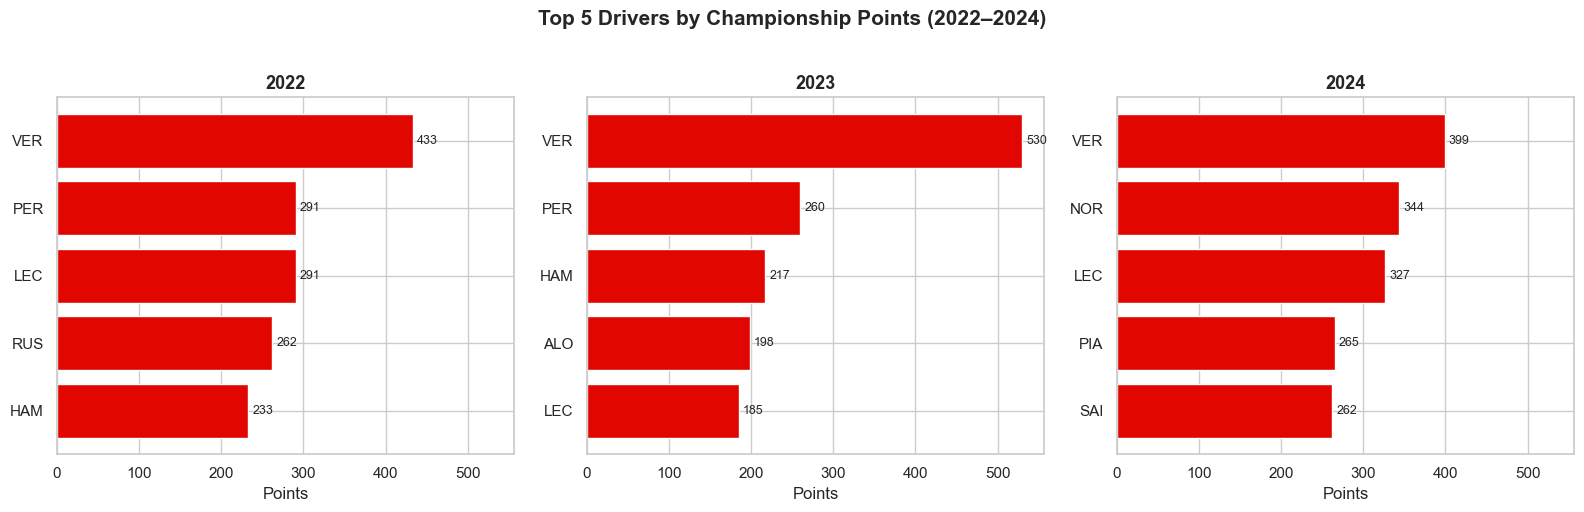

In [11]:
# Top 5 drivers by points for each season
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)

for ax, year in zip(axes, [2022, 2023, 2024]):
    season_data = all_data[all_data["Year"] == year]
    top5 = (season_data.groupby("Abbreviation")["Points"]
                       .sum()
                       .sort_values(ascending=True)
                       .tail(5))

    ax.barh(top5.index, top5.values, color="#E10600")
    ax.set_title(f"{year}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Points")
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)

axes[0].set_ylabel("")
fig.suptitle("Top 5 Drivers by Championship Points (2022–2024)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "chart_champions_by_season.png",
            dpi=120, bbox_inches="tight")
plt.show()

Win rate (%) by season:

TeamName  Ferrari  McLaren  Mercedes  Red Bull Racing
Year                                                 
2022         18.2      0.0       4.5             77.3
2023          4.5      0.0       0.0             95.5
2024         20.8     25.0      16.7             37.5


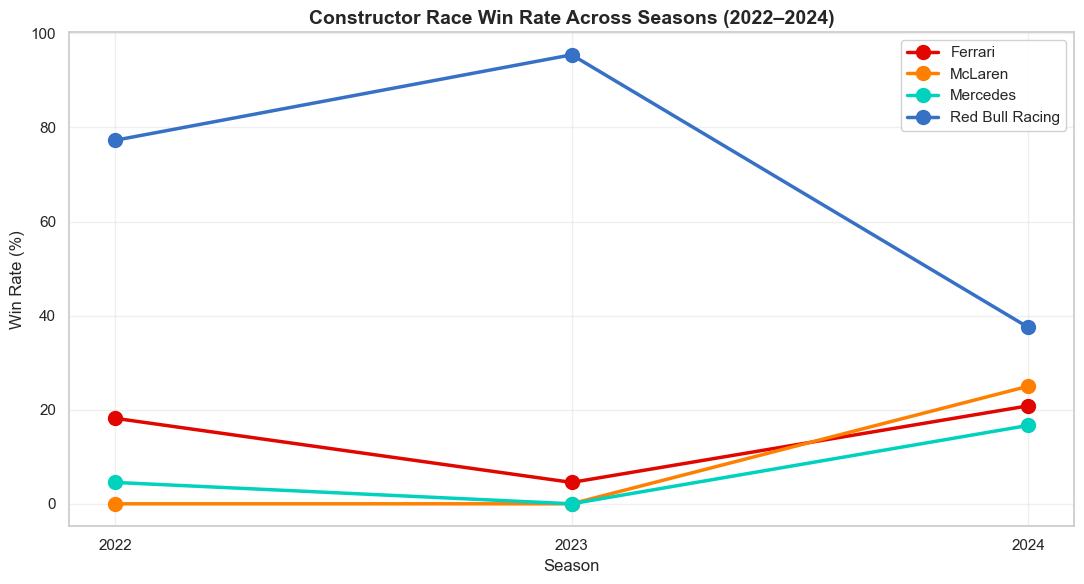

In [12]:
# Win rate per constructor per season
wins = all_data[all_data["Position"] == 1].copy()
constructor_wins = wins.groupby(["Year", "TeamName"]).size().reset_index(name="Wins")

# Total races per year
races_per_year = all_data.groupby("Year")["Round"].nunique().to_dict()
constructor_wins["WinRate"] = constructor_wins.apply(
    lambda r: r["Wins"] / races_per_year[r["Year"]] * 100, axis=1
)

# Pivot for plotting (one column per team)
pivot = constructor_wins.pivot(index="Year", columns="TeamName", values="WinRate").fillna(0)
print("Win rate (%) by season:\n")
print(pivot.round(1))

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
for team in pivot.columns:
    color = TEAM_COLORS.get(team, "#888888")
    ax.plot(pivot.index, pivot[team], marker="o", linewidth=2.5,
            markersize=10, label=team, color=color)

ax.set_title("Constructor Race Win Rate Across Seasons (2022–2024)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Win Rate (%)")
ax.set_xticks([2022, 2023, 2024])
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "chart_constructor_dominance.png",
            dpi=120, bbox_inches="tight")
plt.show()

2022: Pearson correlation = 0.525  (n = 429)
2023: Pearson correlation = 0.581  (n = 437)
2024: Pearson correlation = 0.732  (n = 478)


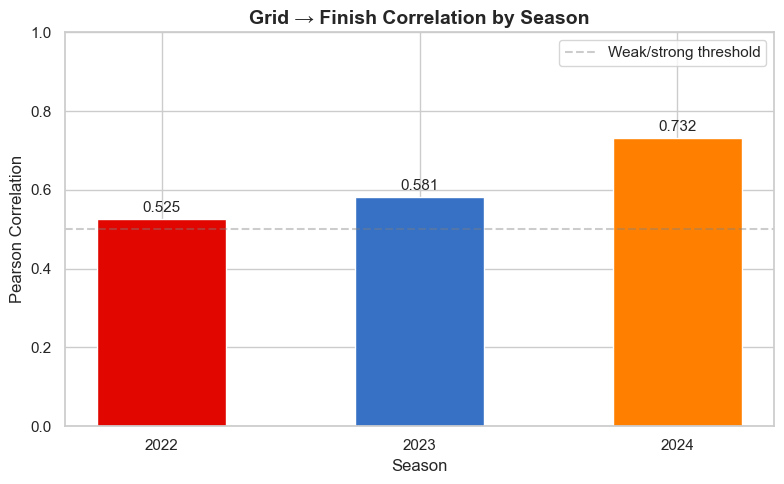

In [14]:
# Calculate grid-vs-finish correlation for each season
correlations = {}
for year in [2022, 2023, 2024]:
    season = all_data[
        (all_data["Year"] == year)
        & all_data["GridPosition"].notna()
        & all_data["Position"].notna()
        & (all_data["GridPosition"] > 0)  # exclude pit-lane starts
    ]
    corr = season[["GridPosition", "Position"]].corr().iloc[0, 1]
    correlations[year] = corr
    print(f"{year}: Pearson correlation = {corr:.3f}  (n = {len(season)})")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
years = list(correlations.keys())
values = list(correlations.values())
bars = ax.bar(years, values, color=["#E10600", "#3671C6", "#FF8000"], width=0.5)

ax.set_title("Grid → Finish Correlation by Season",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Pearson Correlation")
ax.set_xticks(years)
ax.set_ylim(0, 1)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=11)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4, label="Weak/strong threshold")
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "chart_grid_correlation_by_season.png",
            dpi=120, bbox_inches="tight")
plt.show()

## Findings — Multi-Season Analysis (2022–2024)

### 1. Driver dominance shifts dramatically between seasons
Verstappen led the championship in all three seasons, but the gap to second changed enormously:
- **2022**: 142-point lead over PER (regulation reset, RBR ahead of the curve)
- **2023**: 270-point lead — the most dominant single season in F1 history
- **2024**: 55-point lead over NOR — closest at the top in three years

### 2. Constructor balance has shifted significantly
Red Bull's win rate collapsed from 95.5% (2023) to 37.5% (2024), while McLaren went from 0% to 25.0% — the steepest single-season swing in modern F1. Ferrari and Mercedes also recovered.

### 3. Grid position became more predictive each year
| Season | Correlation (Grid → Finish) |
|--------|------------------------------|
| 2022   | 0.525 |
| 2023   | 0.581 |
| 2024   | 0.732 |

This monotonic increase suggests qualifying performance has become a stronger predictor of race outcomes as cars converged after the 2022 regulation reset. **Implication for modelling**: the model must handle this non-stationarity. Training only on the most predictable season would inflate evaluation metrics and produce poor generalisation when regulations or competitive dynamics shift.